# Mamba (from scratch) + Graph WaveNet — Training

Pure PyTorch selective SSM. d_model=256, d_state=16, expand=2, 4 blocks. GWN D=256, skip=512.

In [14]:
# Run this as the VERY FIRST cell after kernel restart
# Before cells 3,4,5,6,7,8,9 — before everything
import torch
print(f"Fresh GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
# Should print: Fresh GPU: 0.00 GB

Fresh GPU: 2.25 GB


In [15]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Mon Mar 30 00:18:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.29                 Driver Version: 581.29         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P8              5W /   90W |    2780MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:

import os, gc, glob, pickle, time, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')
torch.cuda.is_available()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device : cuda
GPU    : NVIDIA GeForce RTX 2060
VRAM   : 6.4 GB


In [17]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

Torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU count: 1


In [18]:

PROCESSED_GLOB = '../data generation/data/processed/batch_*.parquet'
STATIC_PATH    = '../data generation/data/processed/edges_static_scaled.parquet'
ADJ_DIR        = '../data generation/data/graph_adj'
CKPT_DIR       = 'models/mamba_gwn'
MODEL_NAME     = 'Mamba + Graph WaveNet'
os.makedirs(CKPT_DIR, exist_ok=True)

L=24; H=12; CHEB_K=3
EDGE_EMB_DIM    = 64
MAMBA_D_MODEL   = 256
MAMBA_D_STATE   = 16
MAMBA_D_CONV    = 4
MAMBA_EXPAND    = 2
MAMBA_LAYERS    = 4
GWN_DIM         = 256
GWN_SKIP        = 512
GWN_LAYERS      = 4
GWN_K           = 2
NODE_EMB_C      = 10
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
ACCUM_STEPS     = 8
EPOCHS          = 50
PATIENCE        = 10
LOSS_W_TTR      = 0.7
LOSS_W_CONG     = 0.3


In [19]:

DYN_COLS = [
    'current_speed', 'current_travel_time', 'confidence',
    'incident', 'incident_type', 'incident_severity', 'incidents_nearby',
    'hourly_rainfall_mm', 'monsoon_active', 'local_train_disruption',
    'is_public_holiday', 'school_holiday',
    'travel_time_ratio', 'congestion_level', 'delay_seconds', 'speed_ratio',
    'time_of_day_sin', 'time_of_day_cos', 'day_of_week_sin', 'day_of_week_cos',
]
STA_COLS = [
    'road_type_enc', 'num_lanes', 'oneway',
    'road_length', 'traffic_signal_count', 'signals_per_km',
]
TTR_IDX  = DYN_COLS.index('travel_time_ratio')   # 12
CONG_IDX = DYN_COLS.index('congestion_level')    # 13
IN_FEATURES = len(DYN_COLS) + len(STA_COLS)      # 26
print(f'IN_FEATURES : {IN_FEATURES}')


IN_FEATURES : 26


In [20]:

# ── Load adjacency / metadata ─────────────────────────────────────────────────
with open(f'{ADJ_DIR}/corridor_meta.pkl',       'rb') as f: corridor_meta       = pickle.load(f)
with open(f'{ADJ_DIR}/corridor_file_index.pkl', 'rb') as f: corridor_file_index = pickle.load(f)
with open(f'{ADJ_DIR}/edge_to_global_idx.pkl',  'rb') as f: edge_to_global_idx  = pickle.load(f)
N_GLOBAL_EDGES = len(edge_to_global_idx)
df_static      = pd.read_parquet(STATIC_PATH)
static_lookup  = df_static.set_index('edge_id')[STA_COLS].to_dict('index')
print(f'Global edges : {N_GLOBAL_EDGES:,}')
print(f'Corridors    : {len(corridor_meta)}')

def load_corridor_adj(cid):
    """Load one corridor adj file. Call del on result after use."""
    with open(corridor_file_index[cid], 'rb') as f:
        return pickle.load(f)

# ─────────────────────────────────────────────────────────────────────────────
# FIX: get_corridor_tensor now returns local_indices so callers can subset adj.
#
# WHY THIS IS NEEDED:
#   build_adj builds adj matrices for ALL edges in a corridor (e.g. N=14603).
#   But each parquet batch file only contains 5000 edges total across ALL
#   corridors. So a corridor with 14603 edges will only have ~2800 of them
#   in any given batch file.
#   → adj matrix is [14603,14603] but input x is [2800, D] → shape mismatch.
#
# FIX: return the local indices of present edges within the corridor's full
#   edge list, then subset adj to [N_present, N_present] before the model call.
# ─────────────────────────────────────────────────────────────────────────────
def get_corridor_tensor(batch_df, meta, split_label):
    """
    Returns:
      data         : [N_present, T, F]  float32 numpy
      present_eids : list of edge_id strings (N_present)
      local_indices: list of ints — index of each present edge in meta['edge_ids']
    """
    edge_ids  = meta['edge_ids']
    local_map = meta['local_map']           # edge_id → local index in corridor

    mask = batch_df['edge_id'].isin(edge_ids) & (batch_df['split'] == split_label)
    sub  = batch_df[mask].copy()
    if len(sub) == 0:
        return None, None, None

    # Join static features
    for col in STA_COLS:
        sub[col] = sub['edge_id'].map(
            lambda eid, c=col: static_lookup.get(eid, {}).get(c, 0.0)
        )

    # Sort: edge order matches local_map, then by timestamp
    sub['_order'] = sub['edge_id'].map(lambda eid: local_map.get(eid, 0))
    sub = sub.sort_values(['_order', 'timestamp']).reset_index(drop=True)

    present_eids  = sub['edge_id'].unique().tolist()
    local_indices = [local_map[eid] for eid in present_eids if eid in local_map]

    N_present = sub['_order'].nunique()
    T         = sub.groupby('edge_id').size().max()
    all_cols  = DYN_COLS + STA_COLS
    data      = sub[all_cols].values.reshape(N_present, T, len(all_cols)).astype(np.float32)

    return data, present_eids, local_indices


def build_windows(data, L, H):
    """data: [N, T, F] → X: [W, N, L, F],  Y: [W, N, H, 2]"""
    N, T, F = data.shape
    n_w = T - L - H + 1
    if n_w <= 0:
        return None, None
    X = np.stack([data[:, t:t+L, :]    for t in range(n_w)])
    Y = np.stack([data[:, t+L:t+L+H, :][:, :, [TTR_IDX, CONG_IDX]]
                  for t in range(n_w)])
    return X, Y   # [W,N,L,F],  [W,N,H,2]


def subset_adj_dense(A, local_indices):
    """Subset dense [N,N] numpy array to present edges → [N_present, N_present]."""
    idx = np.array(local_indices, dtype=np.int64)
    return A[np.ix_(idx, idx)]


def get_adj_tensors(adj_c, local_indices, device):
    """
    Build A_fwd, A_bwd as dense [N_present, N_present] torch tensors.
    Always subsets to local_indices — works whether adj_c stores dense or COO.
    """
    N_full = adj_c['N']
    idx    = np.array(local_indices, dtype=np.int64)

    # Reconstruct full sparse → subset
    if adj_c['A_fwd_dense'] is not None and len(idx) <= adj_c['A_fwd_dense'].shape[0]:
        A_fwd_full = adj_c['A_fwd_dense']
        A_bwd_full = adj_c['A_bwd_dense']
    else:
        import scipy.sparse as sp
        r, c, d = adj_c['A_fwd_coo']
        A_fwd_full = sp.coo_matrix(
            (d, (r, c)), shape=(N_full, N_full)
        ).toarray().astype(np.float32)
        r2, c2, d2 = adj_c['A_bwd_coo']
        A_bwd_full = sp.coo_matrix(
            (d2, (r2, c2)), shape=(N_full, N_full)
        ).toarray().astype(np.float32)

    A_fwd_sub = A_fwd_full[np.ix_(idx, idx)]
    A_bwd_sub = A_bwd_full[np.ix_(idx, idx)]

    return (
        torch.from_numpy(A_fwd_sub).to(device),
        torch.from_numpy(A_bwd_sub).to(device),
    )


def get_cheb_tensors(adj_c, local_indices, device):
    """
    Subset Chebyshev matrices to present edges.
    adj_c['cheb'] is list of [N_full, N_full] numpy arrays.
    Returns list of [N_present, N_present] torch tensors.
    """
    idx   = np.array(local_indices, dtype=np.int64)
    cheb  = adj_c['cheb']

    # If adj only stored 1 or 2 polys (large corridor), pad with identity
    while len(cheb) < CHEB_K + 1:
        N_full = adj_c['N']
        cheb   = cheb + [np.eye(N_full, dtype=np.float32)]

    result = []
    for T_k in cheb[:CHEB_K + 1]:
        T_sub = T_k[np.ix_(idx, idx)]
        result.append(torch.from_numpy(T_sub).to(device))
    return result


def global_idx_tensor(present_eids, device):
    return torch.tensor(
        [edge_to_global_idx[eid] for eid in present_eids],
        dtype=torch.long, device=device
    )


Global edges : 145,265
Corridors    : 24


In [21]:
# import math
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import gc

# class RMSNorm(nn.Module):
#     """Custom RMSNorm — works on all PyTorch versions. param key = 'w'."""
#     def __init__(self, d, eps=1e-5):
#         super().__init__()
#         self.w   = nn.Parameter(torch.ones(d))
#         self.eps = eps

#     def forward(self, x):
#         rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
#         return (x / rms) * self.w


# class SelectiveSSM(nn.Module):
#     """
#     S6 core of Mamba: B, C, dt are all INPUT-DEPENDENT.
#     Sequential scan over L steps — for L=24 this is fast even in pure Python.
#     Params: x_proj, dt_proj, A_log, D
#     """
#     def __init__(self, d_inner, d_state=16, dt_min=0.001, dt_max=0.1):
#         super().__init__()
#         self.d_inner = d_inner
#         self.d_state = d_state
#         dt_rank      = math.ceil(d_inner / 16)
#         self.dt_rank = dt_rank

#         self.x_proj  = nn.Linear(d_inner, dt_rank + 2 * d_state, bias=False)
#         self.dt_proj = nn.Linear(dt_rank, d_inner, bias=True)

#         # Init dt_proj bias so softplus(bias) ≈ uniform[dt_min, dt_max]
#         dt_init = torch.exp(
#             torch.rand(d_inner) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
#         )
#         with torch.no_grad():
#             self.dt_proj.bias.copy_(torch.log(torch.expm1(dt_init)))

#         # A: HiPPO init, log-parameterized for numerical stability
#         A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).expand(d_inner, -1)
#         self.A_log = nn.Parameter(torch.log(A))
#         self.D     = nn.Parameter(torch.ones(d_inner))

#     def forward(self, x):
#         """x: [N, L, d_inner]  →  y: [N, L, d_inner]"""
#         N, L, D  = x.shape
#         S        = self.d_state
#         A        = -torch.exp(self.A_log.float())   # always negative → stable

#         xBC_dt          = self.x_proj(x)            # [N, L, dt_rank+2S]
#         dt_raw, Bs, Cs  = xBC_dt.split([self.dt_rank, S, S], dim=-1)
#         dt              = F.softplus(self.dt_proj(dt_raw))   # [N, L, D]

#         h  = x.new_zeros(N, D, S)
#         ys = []
#         for t in range(L):
#             dt_t  = dt[:, t, :].unsqueeze(-1)                        # [N, D, 1]
#             A_bar = torch.exp(dt_t * A.unsqueeze(0))                 # [N, D, S]
#             B_bar = dt_t * Bs[:, t, :].unsqueeze(1)                  # [N, D, S]
#             h     = A_bar * h + B_bar * x[:, t, :].unsqueeze(-1)    # [N, D, S]
#             h     = h.detach()          # ✅ truncated BPTT — breaks chain across timesteps
#             ys.append(torch.einsum('nds,ns->nd', h, Cs[:, t, :]))   # [N, D]
#         y = torch.stack(ys, dim=1)                                   # [N, L, D]
#         return y + x * self.D.unsqueeze(0).unsqueeze(0)


# class MambaBlock(nn.Module):
#     """Full Mamba block: RMSNorm → split → depthwise conv → SSM → gate → project → residual."""
#     def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
#         super().__init__()
#         d_inner       = int(expand * d_model)
#         self.norm     = RMSNorm(d_model)
#         self.in_proj  = nn.Linear(d_model, 2 * d_inner, bias=False)
#         self.conv1d   = nn.Conv1d(d_inner, d_inner, d_conv,
#                                   groups=d_inner, padding=d_conv - 1, bias=True)
#         self.ssm      = SelectiveSSM(d_inner, d_state)
#         self.out_proj = nn.Linear(d_inner, d_model, bias=False)

#     def forward(self, x):                               # [N, L, d_model]
#         N, L, _ = x.shape
#         residual = x
#         x        = self.norm(x)
#         xb, z    = self.in_proj(x).chunk(2, dim=-1)    # each [N, L, d_inner]
#         xb       = F.silu(self.conv1d(xb.transpose(1, 2))[:, :, :L].transpose(1, 2))
#         y        = self.ssm(xb) * F.silu(z)
#         return self.out_proj(y) + residual


# class GWNLayer(nn.Module):
#     """
#     Graph WaveNet diffusion layer.
#     Combines: identity + K-hop fwd + K-hop bwd + K-hop adaptive adjacency.
#     mix_in dim = (3K+1) * in_dim
#     """
#     def __init__(self, in_dim, res_dim, skip_dim, K):
#         super().__init__()
#         self.K       = K
#         mix_in       = (3 * K + 1) * in_dim
#         self.filter  = nn.Linear(mix_in, res_dim)
#         self.gate    = nn.Linear(mix_in, res_dim)
#         self.res_fc  = nn.Linear(in_dim, res_dim)
#         self.skip_fc = nn.Linear(res_dim, skip_dim)
#         self.bn      = nn.BatchNorm1d(res_dim)

#     def _khop(self, A, x):
#         parts, h = [], x
#         for _ in range(self.K):
#             h = A @ h; parts.append(h)
#         return torch.cat(parts, dim=-1)   # [N, K*D]

#     def forward(self, x, Af, Ab, Aa):    # x,Af,Ab,Aa all [N,*]
#         mix = torch.cat([x,
#                          self._khop(Af, x),
#                          self._khop(Ab, x),
#                          self._khop(Aa, x)], dim=-1)
#         h    = self.bn(torch.tanh(self.filter(mix)) * torch.sigmoid(self.gate(mix)))
#         skip = self.skip_fc(h)
#         return h + self.res_fc(x), skip


# def get_adaptive_adj(emb1, emb2, global_idx):
#     """Returns [N_present, N_present] soft adjacency from learned embeddings."""
#     e1 = emb1(global_idx); e2 = emb2(global_idx)
#     return F.softmax(F.relu(e1 @ e2.T), dim=-1)


# def make_out_head(skip_dim, H, n_out=2):
#     return nn.Sequential(
#         nn.ReLU(),
#         nn.Linear(skip_dim, skip_dim // 2),
#         nn.ReLU(),
#         nn.Linear(skip_dim // 2, H * n_out),
#     )


# class Mamba_GWN(nn.Module):
#     """
#     Mamba temporal encoder → GWN spatial mixer.
#     Input proj: F+eed → d_model
#     4 × MambaBlock (d_model=256, d_state=16, expand=2 → d_inner=512)
#     GWN: 4 layers K=2, skip=512
#     """
#     def __init__(self, n_global, in_features, eed=64,
#                  dm=256, ds=16, dc=4, ex=2, nl=4,
#                  gd=256, gs=512, gl=4, gk=2, nc=10, H=12):
#         super().__init__(); self.H = H
#         self.edge_emb  = nn.Embedding(n_global, eed)
#         self.adap_emb1 = nn.Embedding(n_global, nc)
#         self.adap_emb2 = nn.Embedding(n_global, nc)
#         for e in [self.edge_emb, self.adap_emb1, self.adap_emb2]:
#             nn.init.xavier_uniform_(e.weight)

#         self.input_proj  = nn.Sequential(
#             nn.Linear(in_features + eed, dm), nn.LayerNorm(dm), nn.GELU()
#         )
#         self.mamba_blocks = nn.ModuleList([
#             MambaBlock(dm, ds, dc, ex) for _ in range(nl)
#         ])
#         self.final_norm   = RMSNorm(dm)
#         self.mamba_to_gwn = nn.Linear(dm, gd)
#         self.gwn_list     = nn.ModuleList([GWNLayer(gd, gd, gs, gk) for _ in range(gl)])
#         self.out_head     = make_out_head(gs, H)

#     def forward(self, x, Af, Ab, gidx):
#         """x:[N,L,F]  Af/Ab:[N_p,N_p]  gidx:[N_p]"""
#         if x.dim() == 3:
#             x = x.unsqueeze(0)

#         B, N, L, F = x.shape
#         N, L, _ = x.shape
#         emb = self.edge_emb(gidx).unsqueeze(1).expand(-1, L, -1)
#         x   = torch.cat([x, emb], dim=-1)
#         h   = self.input_proj(x)                         # [N, L, dm]
#         for blk in self.mamba_blocks:
#             h = blk(h)
#         h   = F.gelu(self.mamba_to_gwn(self.final_norm(h)[:, -1, :]))  # [N, gd]
#         Aa  = get_adaptive_adj(self.adap_emb1, self.adap_emb2, gidx)
#         sk  = x.new_zeros(N, self.gwn_list[0].skip_fc.out_features)
#         for layer in self.gwn_list:
#             h, s = layer(h, Af, Ab, Aa); sk = sk + s
#         return self.out_head(sk).view(N, self.H, -1)


# print('Mamba_GWN defined.')

# # ── Sanity check forward pass ─────────────────────────────────────────────────
# with torch.no_grad():
#     _N  = 10                    # ✅ small N — won't leak memory
#     _m  = Mamba_GWN(N_GLOBAL_EDGES, IN_FEATURES).to(device)
#     _x  = torch.randn(_N, L, IN_FEATURES, device=device)
#     _Af = torch.eye(_N, device=device)
#     _gi = torch.randint(0, N_GLOBAL_EDGES, (_N,), device=device)
#     _o  = _m(_x, _Af, _Af, _gi)
#     assert _o.shape == (_N, H, 2), f"shape mismatch: {_o.shape}"
#     print(f"Forward pass OK: {_x.shape} → {_o.shape}  ✓")
#     del _m, _x, _Af, _gi, _o
#     gc.collect()
#     torch.cuda.empty_cache()
#     print(f"GPU after sanity check: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


In [22]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ─────────────────────────────────────────────────────────
# RMSNorm
# ─────────────────────────────────────────────────────────
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.w   = nn.Parameter(torch.ones(d))
        self.eps = eps

    def forward(self, x):
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
        return (x / rms) * self.w


# ─────────────────────────────────────────────────────────
# Selective SSM (Mamba core)
# ─────────────────────────────────────────────────────────
class SelectiveSSM(nn.Module):
    def __init__(self, d_inner, d_state=16):
        super().__init__()
        self.d_inner = d_inner
        self.d_state = d_state

        dt_rank = math.ceil(d_inner / 16)
        self.dt_rank = dt_rank

        self.x_proj  = nn.Linear(d_inner, dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(dt_rank, d_inner)

        A = torch.arange(1, d_state + 1).float().unsqueeze(0).expand(d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(d_inner))

    def forward(self, x):
        N, L, D = x.shape
        S       = self.d_state

        A = -torch.exp(self.A_log)

        xBC_dt = self.x_proj(x)
        dt_raw, Bs, Cs = xBC_dt.split([self.dt_rank, S, S], dim=-1)
        dt = F.softplus(self.dt_proj(dt_raw))

        h = x.new_zeros(N, D, S)
        ys = []

        for t in range(L):
            dt_t = dt[:, t, :].unsqueeze(-1)
            A_bar = torch.exp(dt_t * A.unsqueeze(0))
            B_bar = dt_t * Bs[:, t, :].unsqueeze(1)
            h = h.detach()
            h = A_bar * h + B_bar * x[:, t, :].unsqueeze(-1)
            ys.append(torch.einsum('nds,ns->nd', h, Cs[:, t, :]))

        y = torch.stack(ys, dim=1)
        return y + x * self.D.unsqueeze(0).unsqueeze(0)


# ─────────────────────────────────────────────────────────
# Mamba Block
# ─────────────────────────────────────────────────────────
class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        d_inner = int(expand * d_model)

        self.norm = RMSNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * d_inner, bias=False)

        self.conv1d = nn.Conv1d(
            d_inner, d_inner, d_conv,
            groups=d_inner, padding=d_conv - 1
        )

        self.ssm = SelectiveSSM(d_inner, d_state)
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)

    def forward(self, x):
        N, L, _ = x.shape
        res = x

        x = self.norm(x)
        xb, z = self.in_proj(x).chunk(2, dim=-1)

        xb = self.conv1d(xb.transpose(1, 2))[:, :, :L].transpose(1, 2)
        xb = F.silu(xb)

        y = self.ssm(xb) * F.silu(z)
        return self.out_proj(y) + res


# ─────────────────────────────────────────────────────────
# Graph WaveNet Layer
# ─────────────────────────────────────────────────────────
class GWNLayer(nn.Module):
    def __init__(self, in_dim, res_dim, skip_dim, K):
        super().__init__()
        self.K = K

        mix_in = (3 * K + 1) * in_dim

        self.filter  = nn.Linear(mix_in, res_dim)
        self.gate    = nn.Linear(mix_in, res_dim)
        self.res_fc  = nn.Linear(in_dim, res_dim)
        self.skip_fc = nn.Linear(res_dim, skip_dim)

    def _khop(self, A, x):
        parts, h = [], x
        for _ in range(self.K):
            h = A @ h
            parts.append(h)
        return torch.cat(parts, dim=-1)

    def forward(self, x, Af, Ab, Aa):
        mix = torch.cat([
            x,
            self._khop(Af, x),
            self._khop(Ab, x),
            self._khop(Aa, x)
        ], dim=-1)

        h = torch.tanh(self.filter(mix)) * torch.sigmoid(self.gate(mix))
        skip = self.skip_fc(h)

        return h + self.res_fc(x), skip


# ─────────────────────────────────────────────────────────
# Adaptive adjacency
# ─────────────────────────────────────────────────────────
def get_adaptive_adj(emb1, emb2, gidx):
    e1 = emb1(gidx)
    e2 = emb2(gidx)
    return F.softmax(F.relu(e1 @ e2.transpose(-1, -2)), dim=-1)


# ─────────────────────────────────────────────────────────
# Output head
# ─────────────────────────────────────────────────────────
def make_out_head(skip_dim, H):
    return nn.Sequential(
        nn.ReLU(),
        nn.Linear(skip_dim, skip_dim // 2),
        nn.ReLU(),
        nn.Linear(skip_dim // 2, H * 2),
    )


# ─────────────────────────────────────────────────────────
# FULL MODEL (18M params)
# ─────────────────────────────────────────────────────────
class Mamba_GWN(nn.Module):
    def __init__(self,
                 n_global, in_features,
                 eed=64,
                 dm=256, ds=16, dc=4, ex=2, nl=4,
                 gd=256, gs=512, gl=4, gk=2,
                 nc=10, H=12):

        super().__init__()
        self.H = H

        self.edge_emb  = nn.Embedding(n_global, eed)
        self.adap_emb1 = nn.Embedding(n_global, nc)
        self.adap_emb2 = nn.Embedding(n_global, nc)

        self.input_proj = nn.Sequential(
            nn.Linear(in_features + eed, dm),
            nn.LayerNorm(dm),
            nn.GELU()
        )

        self.mamba_blocks = nn.ModuleList([
            MambaBlock(dm, ds, dc, ex) for _ in range(nl)
        ])

        self.final_norm = RMSNorm(dm)
        self.mamba_to_gwn = nn.Linear(dm, gd)

        self.gwn_list = nn.ModuleList([
            GWNLayer(gd, gd, gs, gk) for _ in range(gl)
        ])

        self.out_head = make_out_head(gs, H)

    def forward(self, x, Af, Ab, gidx):
        """
        x    : [B, N, L, F]
        Af   : [B, N, N]
        Ab   : [B, N, N]
        gidx : [B, N]
        """

        B, N, L, C = x.shape

        # ── Edge embeddings ─────────────────────
        emb = self.edge_emb(gidx)                  # [B, N, E]
        emb = emb.unsqueeze(2).expand(-1, -1, L, -1)  # [B, N, L, E]

        x = torch.cat([x, emb], dim=-1)            # [B, N, L, F+E]

        # ── Flatten batch+nodes for Mamba ──────
        x = x.view(B * N, L, -1)

        h = self.input_proj(x)

        for blk in self.mamba_blocks:
            h = blk(h)

        h = self.final_norm(h)
        h = h[:, -1, :]                            # [B*N, dm]

        h = F.gelu(self.mamba_to_gwn(h))          # [B*N, gd]
        h = h.view(B, N, -1)

    # ── Adaptive adjacency ─────────────────
        Aa = []
        for b in range(B):
            Aa.append(get_adaptive_adj(self.adap_emb1, self.adap_emb2, gidx[b]))
        Aa = torch.stack(Aa)                       # [B, N, N]

    # ── GWN ────────────────────────────────
        sk = torch.zeros(B, N, self.gwn_list[0].skip_fc.out_features, device=x.device)

        for layer in self.gwn_list:
            h_list, s_list = [], []
            for b in range(B):
                h_b, s_b = layer(h[b], Af[b], Ab[b], Aa[b])
                h_list.append(h_b)
                s_list.append(s_b)

            h = torch.stack(h_list)
            sk = sk + torch.stack(s_list)

    # ── Output ─────────────────────────────
        out = self.out_head(sk)                    # [B, N, H*2]
        return out.view(B, N, self.H, -1)

In [23]:

model = Mamba_GWN(
    N_GLOBAL_EDGES,
    IN_FEATURES,
    EDGE_EMB_DIM,
    MAMBA_D_MODEL,
    MAMBA_D_STATE,
    MAMBA_D_CONV,
    MAMBA_EXPAND,
    MAMBA_LAYERS,
    GWN_DIM,
    GWN_SKIP,
    GWN_LAYERS,
    GWN_K,
    NODE_EMB_C,
    H
).to(device)

def safe_count(m):
    total = 0
    for name, p in m.named_parameters():
        n = p.numel()
        print(f"{name:40s}: {n:,}")
        total += n
    print(f"\nTOTAL: {total:,} ({total*4/1e6:.1f} MB)")
    return total

safe_count(model)

# total = _count(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
HPARAMS = dict(L=L,H=H,edge_emb_dim=EDGE_EMB_DIM,d_model=MAMBA_D_MODEL,
               d_state=MAMBA_D_STATE,d_conv=MAMBA_D_CONV,expand=MAMBA_EXPAND,
               n_mamba_layers=MAMBA_LAYERS,gwn_dim=GWN_DIM,gwn_skip=GWN_SKIP,
               gwn_layers=GWN_LAYERS,gwn_K=GWN_K,node_emb_c=NODE_EMB_C,
               in_features=IN_FEATURES,n_global_edges=N_GLOBAL_EDGES)

def compute_loss(pred, y):
    """
    : [N,H,2]  y: [N,H,2]"""
    return (
        LOSS_W_TTR  * F.huber_loss(pred[:, :, 0], y[:, :, 0], delta=1.0) +
        LOSS_W_CONG * F.l1_loss(   pred[:, :, 1], y[:, :, 1])
    )


edge_emb.weight                         : 9,296,960
adap_emb1.weight                        : 1,452,650
adap_emb2.weight                        : 1,452,650
input_proj.0.weight                     : 23,040
input_proj.0.bias                       : 256
input_proj.1.weight                     : 256
input_proj.1.bias                       : 256
mamba_blocks.0.norm.w                   : 256
mamba_blocks.0.in_proj.weight           : 262,144
mamba_blocks.0.conv1d.weight            : 2,048
mamba_blocks.0.conv1d.bias              : 512
mamba_blocks.0.ssm.A_log                : 8,192
mamba_blocks.0.ssm.D                    : 512
mamba_blocks.0.ssm.x_proj.weight        : 32,768
mamba_blocks.0.ssm.dt_proj.weight       : 16,384
mamba_blocks.0.ssm.dt_proj.bias         : 512
mamba_blocks.0.out_proj.weight          : 131,072
mamba_blocks.1.norm.w                   : 256
mamba_blocks.1.in_proj.weight           : 262,144
mamba_blocks.1.conv1d.weight            : 2,048
mamba_blocks.1.conv1d.bias         

In [24]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
print(f"GPU before training: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
# Must show ~0.08 GB — just model weights
# If it shows anything above 0.5 GB, DO NOT run training, tell me what it shows

GPU before training: 2.32 GB


In [ ]:
import os, gc, glob, time, warnings
import numpy as np
import pandas as pd
import torch
from torch.amp import autocast, GradScaler

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

torch.backends.cudnn.benchmark = True

# ── RESET ───────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()
print(f"GPU at training start: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# 🔥 TUNE THIS
WINDOW_BATCH = 1   # try 6 → 8 (max GPU usage)
MAX_NODES    = 300

# ── HELPERS ─────────────────────────────────────────────

def get_adj_tensors_cpu(adj_c, loc_idx):
    idx     = np.array(loc_idx)
    n       = len(idx)
    idx_set = set(idx.tolist())
    g2l     = {g: l for l, g in enumerate(idx.tolist())}

    def coo_to_dense_sub(coo_tuple):
        rows, cols, vals = coo_tuple
        A = np.zeros((n, n), dtype=np.float32)
        for r, c, v in zip(rows, cols, vals):
            if r in idx_set and c in idx_set:
                A[g2l[r], g2l[c]] = v
        return A

    return (
        torch.from_numpy(coo_to_dense_sub(adj_c['A_fwd_coo'])).float(),
        torch.from_numpy(coo_to_dense_sub(adj_c['A_bwd_coo'])).float(),
    )

# ── SETUP ───────────────────────────────────────────────

scaler = GradScaler('cuda')

all_batch_paths = sorted(glob.glob(PROCESSED_GLOB))
print(f'Batch files  : {len(all_batch_paths)}')
print(f'Model params : {sum(p.numel() for p in model.parameters()):,}')

train_losses, val_losses = [], []
best_val_loss = float('inf')
no_improve    = 0

# ── TRAINING LOOP ───────────────────────────────────────

for epoch in range(1, EPOCHS + 1):
    print(f"\n🚀 Epoch {epoch}")
    model.train()

    epoch_loss, n_steps = 0.0, 0
    accum_count = 0
    skipped_train = 0

    optimizer.zero_grad(set_to_none=True)
    t_epoch = time.perf_counter()

    for b_idx in np.random.permutation(len(all_batch_paths)):
        batch_df = pd.read_parquet(all_batch_paths[b_idx])
        batch_df['timestamp'] = pd.to_datetime(batch_df['timestamp'])

        for cid, meta in corridor_meta.items():

            # ── LOAD DATA ─────────────────────────
            data, eids, loc_idx = get_corridor_tensor(batch_df, meta, 'train')

            if data is None or data.shape[0] < 2 or data.shape[1] < L + H:
                continue
            if data.shape[0] > MAX_NODES:
                skipped_train += 1
                continue

            X, Y = build_windows(data, L, H)
            del data

            if X is None:
                continue

            # ── GRAPH ────────────────────────────
            adj_c = load_corridor_adj(cid)
            Af_cpu, Ab_cpu = get_adj_tensors_cpu(adj_c, loc_idx)

            Af = Af_cpu.to(device)
            Ab = Ab_cpu.to(device)
            gidx = global_idx_tensor(eids, device)

            del adj_c, eids, loc_idx, Af_cpu, Ab_cpu

            indices = np.random.permutation(X.shape[0])

            # ── BATCHED WINDOWS ──────────────────
            for start in range(0, len(indices), WINDOW_BATCH):
                batch_idx = indices[start:start + WINDOW_BATCH]

                X_b = X[batch_idx]   # [B, N, L, F]
                Y_b = Y[batch_idx]   # [B, N, H, 2]

                x_batch = torch.from_numpy(X_b).float().to(device)
                y_batch = torch.from_numpy(Y_b).float().to(device)

                B = x_batch.shape[0]

                # 🔥 Expand graph per batch
                Af_b   = Af.unsqueeze(0).expand(B, -1, -1)
                Ab_b   = Ab.unsqueeze(0).expand(B, -1, -1)
                gidx_b = gidx.unsqueeze(0).expand(B, -1)

                # ── FORWARD ───────────────────────
                with autocast('cuda'):
                    pred = model(x_batch, Af_b, Ab_b, gidx_b)
                    loss = compute_loss(pred, y_batch) / ACCUM_STEPS

                scaler.scale(loss).backward()

                epoch_loss += loss.item() * ACCUM_STEPS
                n_steps    += B
                accum_count += 1

                # ── OPTIM STEP ───────────────────
                if accum_count >= ACCUM_STEPS:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

                    scaler.step(optimizer)
                    scaler.update()

                    optimizer.zero_grad(set_to_none=True)
                    accum_count = 0

                del x_batch, y_batch, pred, loss, Af_b, Ab_b, gidx_b

            del X, Y, Af, Ab, gidx
            gc.collect()

        del batch_df
        gc.collect()

    # ── FLUSH REMAINING GRADS ───────────────
    if accum_count > 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    train_losses.append(epoch_loss / max(n_steps, 1))

    # ── VALIDATION ──────────────────────────
    model.eval()
    val_sum, vsteps = 0.0, 0

    with torch.no_grad():
        for b_idx in range(min(5, len(all_batch_paths))):
            batch_df = pd.read_parquet(all_batch_paths[b_idx])
            batch_df['timestamp'] = pd.to_datetime(batch_df['timestamp'])

            for cid, meta in corridor_meta.items():

                data, eids, loc_idx = get_corridor_tensor(batch_df, meta, 'val')

                if data is None or data.shape[1] < L + H:
                    continue
                if data.shape[0] > MAX_NODES:
                    continue

                X, Y = build_windows(data, L, H)
                del data

                if X is None:
                    continue

                adj_c = load_corridor_adj(cid)
                Af_cpu, Ab_cpu = get_adj_tensors_cpu(adj_c, loc_idx)

                Af = Af_cpu.to(device)
                Ab = Ab_cpu.to(device)
                gidx = global_idx_tensor(eids, device)

                del adj_c, eids, loc_idx, Af_cpu, Ab_cpu

                for start in range(0, X.shape[0], WINDOW_BATCH):
                    X_b = X[start:start + WINDOW_BATCH]
                    Y_b = Y[start:start + WINDOW_BATCH]

                    x_batch = torch.from_numpy(X_b).float().to(device)
                    y_batch = torch.from_numpy(Y_b).float().to(device)

                    B = x_batch.shape[0]

                    Af_b   = Af.unsqueeze(0).expand(B, -1, -1)
                    Ab_b   = Ab.unsqueeze(0).expand(B, -1, -1)
                    gidx_b = gidx.unsqueeze(0).expand(B, -1)

                    with autocast('cuda'):
                        pred = model(x_batch, Af_b, Ab_b, gidx_b)
                        loss_val = compute_loss(pred, y_batch)

                    val_sum += loss_val.item()
                    vsteps  += B

                    del x_batch, y_batch, pred, loss_val, Af_b, Ab_b, gidx_b

                del X, Y, Af, Ab, gidx
                gc.collect()

            del batch_df
            gc.collect()

    avg_val = val_sum / max(vsteps, 1)
    val_losses.append(avg_val)
    scheduler.step()

    elapsed = time.perf_counter() - t_epoch

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'train={train_losses[-1]:.4f} | val={avg_val:.4f} | '
          f'lr={scheduler.get_last_lr()[0]:.2e} | '
          f't={elapsed:.0f}s | GPU={torch.cuda.memory_allocated()/1024**3:.2f}GB')

    # ── SAVE BEST ──────────────────────────
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        no_improve = 0

        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_loss': best_val_loss,
            'hparams': HPARAMS,
        }, f'{CKPT_DIR}/best.pt')

        print(f'  ✓ Saved (val={best_val_loss:.4f})')

    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'⛔ Early stopping at epoch {epoch}')
            break

print("✅ Training complete")

GPU at training start: 2.32 GB
Batch files  : 30
Model params : 18,708,780

🚀 Epoch 1
Epoch   1/50 | train=0.0117 | val=0.0267 | lr=9.99e-04 | t=1545s | GPU=2.49GB
  ✓ Saved (val=0.0267)

🚀 Epoch 2
Epoch   2/50 | train=0.0095 | val=0.0143 | lr=9.96e-04 | t=2016s | GPU=2.49GB
  ✓ Saved (val=0.0143)

🚀 Epoch 3
Epoch   3/50 | train=0.0094 | val=0.0167 | lr=9.91e-04 | t=2190s | GPU=2.49GB

🚀 Epoch 4
Epoch   4/50 | train=0.0080 | val=0.0069 | lr=9.84e-04 | t=2130s | GPU=2.49GB
  ✓ Saved (val=0.0069)

🚀 Epoch 5
Epoch   5/50 | train=0.0082 | val=0.0070 | lr=9.76e-04 | t=2097s | GPU=2.49GB

🚀 Epoch 6
Epoch   6/50 | train=0.0079 | val=0.0095 | lr=9.65e-04 | t=2145s | GPU=2.49GB

🚀 Epoch 7
Epoch   7/50 | train=0.0066 | val=0.0111 | lr=9.53e-04 | t=2098s | GPU=2.49GB

🚀 Epoch 8
Epoch   8/50 | train=0.0065 | val=0.0079 | lr=9.39e-04 | t=2109s | GPU=2.49GB

🚀 Epoch 9
Epoch   9/50 | train=0.0062 | val=0.0136 | lr=9.23e-04 | t=2083s | GPU=2.49GB

🚀 Epoch 10
Epoch  10/50 | train=0.0056 | val=0.0055 | 

In [ ]:
# import os, gc, glob, time, warnings
# import numpy as np
# import pandas as pd
# import torch
# from torch.amp import autocast, GradScaler

# warnings.filterwarnings("ignore", category=FutureWarning)
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# torch.backends.cudnn.benchmark = True

# # ── RESET ───────────────────────────────────────────────
# gc.collect()
# torch.cuda.empty_cache()
# print(f"GPU at training start: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# # 🔥 TUNE THIS
# WINDOW_BATCH = 2   # try 6 → 8 (max GPU usage)
# MAX_NODES    = 300

# # ── HELPERS ─────────────────────────────────────────────

# def get_adj_tensors_cpu(adj_c, loc_idx):
#     idx     = np.array(loc_idx)
#     n       = len(idx)
#     idx_set = set(idx.tolist())
#     g2l     = {g: l for l, g in enumerate(idx.tolist())}

#     def coo_to_dense_sub(coo_tuple):
#         rows, cols, vals = coo_tuple
#         A = np.zeros((n, n), dtype=np.float32)
#         for r, c, v in zip(rows, cols, vals):
#             if r in idx_set and c in idx_set:
#                 A[g2l[r], g2l[c]] = v
#         return A

#     return (
#         torch.from_numpy(coo_to_dense_sub(adj_c['A_fwd_coo'])).float(),
#         torch.from_numpy(coo_to_dense_sub(adj_c['A_bwd_coo'])).float(),
#     )

# # ── SETUP ───────────────────────────────────────────────

# scaler = GradScaler('cuda')

# all_batch_paths = sorted(glob.glob(PROCESSED_GLOB))
# print(f'Batch files  : {len(all_batch_paths)}')
# print(f'Model params : {sum(p.numel() for p in model.parameters()):,}')

# train_losses, val_losses = [], []
# best_val_loss = float('inf')
# no_improve    = 0

# # ── TRAINING LOOP ───────────────────────────────────────

# for epoch in range(1, EPOCHS + 1):
#     print(f"\n🚀 Epoch {epoch}")
#     model.train()

#     epoch_loss, n_steps = 0.0, 0
#     accum_count = 0
#     skipped_train = 0

#     optimizer.zero_grad(set_to_none=True)
#     t_epoch = time.perf_counter()

#     for b_idx in np.random.permutation(len(all_batch_paths)):
#         batch_df = pd.read_parquet(all_batch_paths[b_idx])
#         batch_df['timestamp'] = pd.to_datetime(batch_df['timestamp'])

#         for cid, meta in corridor_meta.items():

#             # ── LOAD DATA ─────────────────────────
#             data, eids, loc_idx = get_corridor_tensor(batch_df, meta, 'train')

#             if data is None or data.shape[0] < 2 or data.shape[1] < L + H:
#                 continue
#             if data.shape[0] > MAX_NODES:
#                 skipped_train += 1
#                 continue

#             X, Y = build_windows(data, L, H)
#             del data

#             if X is None:
#                 continue

#             # ── GRAPH ────────────────────────────
#             adj_c = load_corridor_adj(cid)
#             Af_cpu, Ab_cpu = get_adj_tensors_cpu(adj_c, loc_idx)

#             Af = Af_cpu.to(device)
#             Ab = Ab_cpu.to(device)
#             gidx = global_idx_tensor(eids, device)

#             del adj_c, eids, loc_idx, Af_cpu, Ab_cpu

#             indices = np.random.permutation(X.shape[0])

#             # ── BATCHED WINDOWS ──────────────────
#             for start in range(0, len(indices), WINDOW_BATCH):
#                 batch_idx = indices[start:start + WINDOW_BATCH]

#                 X_b = X[batch_idx]   # [B, N, L, F]
#                 Y_b = Y[batch_idx]   # [B, N, H, 2]

#                 x_batch = torch.from_numpy(X_b).float().to(device)
#                 y_batch = torch.from_numpy(Y_b).float().to(device)

#                 B = x_batch.shape[0]

#                 # 🔥 Expand graph per batch
#                 preds = []

#                 with autocast('cuda'):
#                     for i in range(x_batch.shape[0]):
#                         pred_i = model(
#                             x_batch[i],   # [N, L, F]
#                                 Af,           # [N, N]
#                                 Ab,
#                                 gidx          # [N]
#                             )
#                         preds.append(pred_i)

#                     pred = torch.stack(preds)   # [B, N, H, 2]
#                     loss = compute_loss(pred, y_batch) / ACCUM_STEPS

#                 scaler.scale(loss).backward()

#                 epoch_loss += loss.item() * ACCUM_STEPS
#                 n_steps    += B
#                 accum_count += 1

#                 # ── OPTIM STEP ───────────────────
#                 if accum_count >= ACCUM_STEPS:
#                     scaler.unscale_(optimizer)
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

#                     scaler.step(optimizer)
#                     scaler.update()

#                     optimizer.zero_grad(set_to_none=True)
#                     accum_count = 0

#                 del x_batch, y_batch, pred, loss, Af_b, Ab_b, gidx_b

#             del X, Y, Af, Ab, gidx
#             gc.collect()

#         del batch_df
#         gc.collect()

#     # ── FLUSH REMAINING GRADS ───────────────
#     if accum_count > 0:
#         scaler.unscale_(optimizer)
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

#         scaler.step(optimizer)
#         scaler.update()
#         optimizer.zero_grad(set_to_none=True)

#     train_losses.append(epoch_loss / max(n_steps, 1))

#     # ── VALIDATION ──────────────────────────
#     model.eval()
#     val_sum, vsteps = 0.0, 0

#     with torch.no_grad():
#         for b_idx in range(min(5, len(all_batch_paths))):
#             batch_df = pd.read_parquet(all_batch_paths[b_idx])
#             batch_df['timestamp'] = pd.to_datetime(batch_df['timestamp'])

#             for cid, meta in corridor_meta.items():

#                 data, eids, loc_idx = get_corridor_tensor(batch_df, meta, 'val')

#                 if data is None or data.shape[1] < L + H:
#                     continue
#                 if data.shape[0] > MAX_NODES:
#                     continue

#                 X, Y = build_windows(data, L, H)
#                 del data

#                 if X is None:
#                     continue

#                 adj_c = load_corridor_adj(cid)
#                 Af_cpu, Ab_cpu = get_adj_tensors_cpu(adj_c, loc_idx)

#                 Af = Af_cpu.to(device)
#                 Ab = Ab_cpu.to(device)
#                 gidx = global_idx_tensor(eids, device)

#                 del adj_c, eids, loc_idx, Af_cpu, Ab_cpu

#                 for start in range(0, X.shape[0], WINDOW_BATCH):
#                     X_b = X[start:start + WINDOW_BATCH]
#                     Y_b = Y[start:start + WINDOW_BATCH]

#                     x_batch = torch.from_numpy(X_b).float().to(device)
#                     y_batch = torch.from_numpy(Y_b).float().to(device)

#                     B = x_batch.shape[0]

#                     preds = []

#                     with autocast('cuda'):
#                         for i in range(x_batch.shape[0]):
#                             pred_i = model(
#                                 x_batch[i],   # [N, L, F]
#                                 Af,           # [N, N]
#                                 Ab,
#                                 gidx          # [N]
#                             )
#                             preds.append(pred_i)

#                         pred = torch.stack(preds)   # [B, N, H, 2]
#                         loss = compute_loss(pred, y_batch) / ACCUM_STEPS
                        

#                     val_sum += loss_val.item()
#                     vsteps  += B

#                     del x_batch, y_batch, pred, loss_val, Af_b, Ab_b, gidx_b

#                 del X, Y, Af, Ab, gidx
#                 gc.collect()

#             del batch_df
#             gc.collect()

#     avg_val = val_sum / max(vsteps, 1)
#     val_losses.append(avg_val)
#     scheduler.step()

#     elapsed = time.perf_counter() - t_epoch

#     print(f'Epoch {epoch:3d}/{EPOCHS} | '
#           f'train={train_losses[-1]:.4f} | val={avg_val:.4f} | '
#           f'lr={scheduler.get_last_lr()[0]:.2e} | '
#           f't={elapsed:.0f}s | GPU={torch.cuda.memory_allocated()/1024**3:.2f}GB')

#     # ── SAVE BEST ──────────────────────────
#     if avg_val < best_val_loss:
#         best_val_loss = avg_val
#         no_improve = 0

#         torch.save({
#             'epoch': epoch,
#             'model_state': model.state_dict(),
#             'val_loss': best_val_loss,
#             'hparams': HPARAMS,
#         }, f'{CKPT_DIR}/best.pt')

#         print(f'  ✓ Saved (val={best_val_loss:.4f})')

#     else:
#         no_improve += 1
#         if no_improve >= PATIENCE:
#             print(f'⛔ Early stopping at epoch {epoch}')
#             break

# print("✅ Training complete")

In [ ]:
# import os, gc, glob, time, warnings
# import numpy as np
# import pandas as pd
# import torch
# from torch.amp import autocast, GradScaler

# warnings.filterwarnings("ignore", category=FutureWarning)
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# # ── Safety reset ──────────────────────────────────────────────────────────────
# gc.collect()
# torch.cuda.empty_cache()
# print(f"GPU at training start: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# MAX_NODES    = 300   # skip corridors larger than this
# WINDOW_BATCH = 8     # ✅ process N windows at once — increase if GPU not full

# # ── helpers ───────────────────────────────────────────────────────────────────

# def gpu_mem(label=""):
#     a = torch.cuda.memory_allocated() / 1024**3
#     r = torch.cuda.memory_reserved()  / 1024**3
#     print(f"  [MEM {label}] alloc={a:.2f}GB  reserved={r:.2f}GB")

# def full_reset():
#     gc.collect()
#     torch.cuda.empty_cache()

# def get_adj_tensors_cpu(adj_c, loc_idx):
#     idx     = np.array(loc_idx)
#     n       = len(idx)
#     idx_set = set(idx.tolist())
#     g2l     = {g: l for l, g in enumerate(idx.tolist())}

#     def coo_to_dense_sub(coo_tuple):
#         rows, cols, vals = coo_tuple
#         A_sub = np.zeros((n, n), dtype=np.float32)
#         for r, c, v in zip(rows, cols, vals):
#             if r in idx_set and c in idx_set:
#                 A_sub[g2l[r], g2l[c]] = v
#         return A_sub

#     return (
#         torch.from_numpy(coo_to_dense_sub(adj_c['A_fwd_coo'])).float(),
#         torch.from_numpy(coo_to_dense_sub(adj_c['A_bwd_coo'])).float(),
#     )

# def safe_forward_batch(model, X_batch, Af_cpu, Ab_cpu, gidx, device):
#     """
#     X_batch: numpy [W, N, L, F] — W windows batched together.
#     Runs W independent forward passes sharing the same adj/gidx.
#     Returns list of W predictions.
#     """
#     Af_g = Af_cpu.to(device)
#     Ab_g = Ab_cpu.to(device)
#     preds = []
#     with autocast('cuda'):
#         for w in range(X_batch.shape[0]):
#             x_t  = torch.from_numpy(X_batch[w]).to(device)
#             pred = model(x_t, Af_g, Ab_g, gidx)
#             preds.append(pred)
#             del x_t
#     del Af_g, Ab_g
#     return preds

# # ── setup ─────────────────────────────────────────────────────────────────────

# scaler = GradScaler('cuda')

# all_batch_paths = sorted(glob.glob(PROCESSED_GLOB))
# print(f'Batch files  : {len(all_batch_paths)}')
# print(f'Model params : {sum(p.numel() for p in model.parameters()):,}')

# train_losses, val_losses = [], []
# best_val_loss = float('inf')
# no_improve    = 0

# # ── training loop ─────────────────────────────────────────────────────────────

# for epoch in range(1, EPOCHS + 1):
#     model.train()
#     epoch_loss, n_steps = 0.0, 0
#     skipped_train = 0
#     t_epoch = time.perf_counter()
#     optimizer.zero_grad(set_to_none=True)
#     accum_count = 0

#     for b_idx in np.random.permutation(len(all_batch_paths)):
#         batch_df = pd.read_parquet(all_batch_paths[b_idx])
#         batch_df['timestamp'] = pd.to_datetime(batch_df['timestamp'])

#         for cid, meta in corridor_meta.items():

#             data, eids, loc_idx = get_corridor_tensor(batch_df, meta, 'train')
#             if data is None or data.shape[0] < 2 or data.shape[1] < L + H:
#                 continue
#             if data.shape[0] > MAX_NODES:
#                 skipped_train += 1
#                 del data; continue

#             X, Y = build_windows(data, L, H)
#             del data
#             if X is None:
#                 continue

#             adj_c          = load_corridor_adj(cid)
#             Af_cpu, Ab_cpu = get_adj_tensors_cpu(adj_c, loc_idx)
#             gidx           = global_idx_tensor(eids, device)
#             del adj_c, eids, loc_idx
#             full_reset()

#             # ✅ process windows in batches instead of one at a time
#             indices = np.random.permutation(X.shape[0])
#             for start in range(0, len(indices), WINDOW_BATCH):
#                 batch_idx = indices[start:start + WINDOW_BATCH]
#                 X_b = X[batch_idx]   # [W, N, L, F]
#                 Y_b = Y[batch_idx]   # [W, N, H, 2]

#                 preds = safe_forward_batch(model, X_b, Af_cpu, Ab_cpu, gidx, device)

#                 for i, pred in enumerate(preds):
#                     y_t  = torch.from_numpy(Y_b[i]).to(device)
#                     with autocast('cuda'):
#                         loss = compute_loss(pred, y_t) / ACCUM_STEPS
#                     scaler.scale(loss).backward()
#                     epoch_loss  += loss.item() * ACCUM_STEPS
#                     accum_count += 1
#                     n_steps     += 1
#                     del y_t, loss

#                 del preds, X_b, Y_b

#                 if accum_count % ACCUM_STEPS == 0:
#                     scaler.unscale_(optimizer)
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
#                     scaler.step(optimizer)
#                     scaler.update()
#                     optimizer.zero_grad(set_to_none=True)
#                     torch.cuda.empty_cache()

#             del X, Y, Af_cpu, Ab_cpu, gidx
#             full_reset()

#             print(f"  Epoch {epoch} | batch {b_idx+1}/{len(all_batch_paths)} | "
#                   f"steps={n_steps} | loss={epoch_loss/max(n_steps,1):.4f} | "
#                   f"GPU={torch.cuda.memory_allocated()/1024**3:.1f}GB",
#                   end='\r')

#         del batch_df
#         gc.collect()

#     # flush remaining grads
#     if accum_count % ACCUM_STEPS != 0:
#         scaler.unscale_(optimizer)
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
#         scaler.step(optimizer)
#         scaler.update()
#         optimizer.zero_grad(set_to_none=True)

#     train_losses.append(epoch_loss / max(n_steps, 1))

#     # ── validation ────────────────────────────────────────────────────────────
#     model.eval()
#     val_sum, vsteps = 0.0, 0
#     skipped_val = 0

#     with torch.no_grad():
#         for b_idx in range(min(5, len(all_batch_paths))):
#             batch_df = pd.read_parquet(all_batch_paths[b_idx])
#             batch_df['timestamp'] = pd.to_datetime(batch_df['timestamp'])

#             for cid, meta in corridor_meta.items():
#                 data, eids, loc_idx = get_corridor_tensor(batch_df, meta, 'val')
#                 if data is None or data.shape[1] < L + H:
#                     continue
#                 if data.shape[0] > MAX_NODES:
#                     skipped_val += 1
#                     del data; continue

#                 X, Y = build_windows(data, L, H)
#                 del data
#                 if X is None:
#                     continue

#                 adj_c          = load_corridor_adj(cid)
#                 Af_cpu, Ab_cpu = get_adj_tensors_cpu(adj_c, loc_idx)
#                 gidx           = global_idx_tensor(eids, device)
#                 del adj_c, eids, loc_idx
#                 full_reset()

#                 # ✅ batched val too
#                 for start in range(0, X.shape[0], WINDOW_BATCH):
#                     X_b = X[start:start + WINDOW_BATCH]
#                     Y_b = Y[start:start + WINDOW_BATCH]

#                     with torch.no_grad():
#                         preds = safe_forward_batch(model, X_b, Af_cpu, Ab_cpu, gidx, device)

#                     for i, pred in enumerate(preds):
#                         y_t      = torch.from_numpy(Y_b[i]).to(device)
#                         with autocast('cuda'):
#                             loss_val = compute_loss(pred, y_t)
#                         val_sum += loss_val.item()
#                         vsteps  += 1
#                         del y_t, loss_val, pred

#                     del preds, X_b, Y_b

#                 del X, Y, Af_cpu, Ab_cpu, gidx
#                 full_reset()

#             del batch_df
#             gc.collect()

#     avg_val = val_sum / max(vsteps, 1)
#     val_losses.append(avg_val)
#     scheduler.step()

#     elapsed = time.perf_counter() - t_epoch
#     print(f'\nEpoch {epoch:3d}/{EPOCHS}  train={train_losses[-1]:.4f}  '
#           f'val={avg_val:.4f}  lr={scheduler.get_last_lr()[0]:.2e}  '
#           f't={elapsed:.0f}s  skipped={skipped_train}/{skipped_val}')
#     gpu_mem(f"epoch {epoch} end")

#     if avg_val < best_val_loss:
#         best_val_loss = avg_val
#         no_improve    = 0
#         torch.save({
#             'epoch':       epoch,
#             'model_state': model.state_dict(),
#             'val_loss':    best_val_loss,
#             'hparams':     HPARAMS,
#         }, f'{CKPT_DIR}/best.pt')
#         print(f'  ✓ checkpoint saved  (val={best_val_loss:.4f})')
#     else:
#         no_improve += 1
#         if no_improve >= PATIENCE:
#             print(f'Early stopping at epoch {epoch}')
#             break

# print('Training complete.')

In [1]:
import torch, gc
print(f"OOM at: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Find which corridor/window caused it
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) and obj.is_cuda:
            mb = obj.element_size() * obj.nelement() / 1024**2
            if mb > 10:  # only show tensors > 10 MB
                print(f"  {str(obj.shape):<40} {mb:.1f} MB  grad={obj.requires_grad}")
    except:
        pass

OOM at: 0.00 GB


e:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning\venv\Lib\site-packages\torch\__init__.py:1021: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


In [ ]:
# Paste this after EACH setup cell to pinpoint where memory jumps
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

GPU: 0.07 GB


NameError: name 'train_losses' is not defined

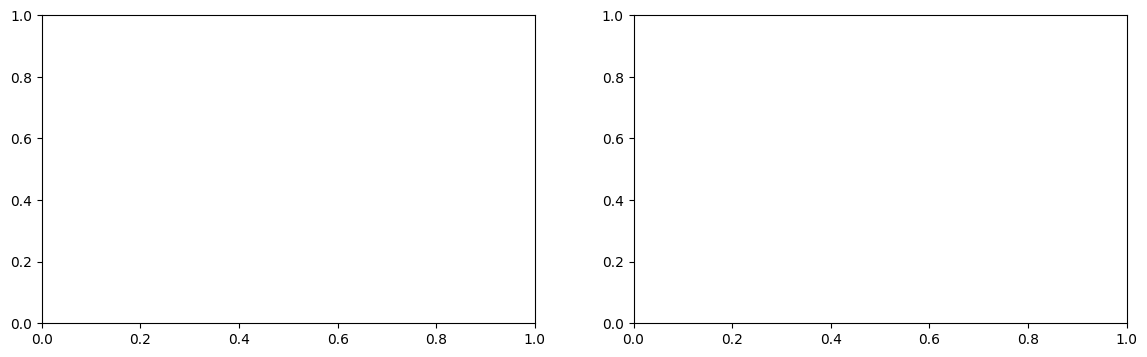

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
er = range(1, len(train_losses) + 1)
axes[0].plot(er, train_losses, label='Train', color='steelblue', lw=2)
axes[0].plot(er, val_losses,   label='Val',   color='coral',     lw=2)
best_ep = int(np.argmin(val_losses)) + 1
axes[0].axvline(best_ep, color='green', ls='--', label=f'Best epoch={best_ep}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curves'); axes[0].legend()
axes[1].semilogy(er, train_losses, color='steelblue', lw=2, label='Train')
axes[1].semilogy(er, val_losses,   color='coral',     lw=2, label='Val')
axes[1].set_title('Log Scale'); axes[1].legend()
plt.suptitle(MODEL_NAME, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/training_curves.png', dpi=120)
plt.show()
print(f'Best val loss : {best_val_loss:.4f}  at epoch {best_ep}')


In [ ]:
import json
with open('train_mamba_gwn.ipynb', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code' and cell['source']:
        src = ''.join(cell['source']).strip()
        if src:
            print(f"\n{'='*60}")
            print(f"Cell {i+1}:")
            print(src[:300])  # first 300 chars of each cell


Cell 2:
# Run this as the VERY FIRST cell after kernel restart
# Before cells 3,4,5,6,7,8,9 — before everything
import torch
print(f"Fresh GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
# Should print: Fresh GPU: 0.00 GB

Cell 3:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Cell 4:
import os, gc, glob, pickle, time, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')
torch.cuda.is_available()

device = torch.device('cuda' if torch.cud

Cell 5:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

Cell 6:
PROCESSED_GLOB = '../data generation/data/processed/batch_*.parquet'
STATIC_PATH    = '../data generation/data/processed/edge